# Ethiopia Food Prices — 13 FINAL MODELS (cereals & tubers)

Closes out the project: attempts the fix `09`/`11`/`12` identified for the price regressor (a log-scale
target), makes a final call on each model, retrains the chosen models on **all** available data for
production use, generates genuine forward forecasts for the next unseen month, and documents everything in
a model card.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json
from datetime import datetime

from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

cfg = json.load(open('../models/09_feature_config_cereals.json'))
NUM = cfg['numeric_features']
CAT = cfg['categorical_features']
CUTOFF = pd.Timestamp(cfg['cutoff_date'])

df = pd.read_csv('../data/eth_food_prices_features_cereals.csv', parse_dates=['date'])
print(f'{len(df):,} rows loaded, data through {df["date"].max().date()}')


23,883 rows loaded, data through 2026-07-15


## 13.1 Decisions carried in from `11 MODEL COMPARISON`

| Task | Winner | Status |
|---|---|---|
| Single-series national forecasting | Drift | Final — no further work planned |
| Panel-level next-month price (regression) | Persistence, provisionally | **Re-examined below** (§13.2) before finalizing |
| Next-month spike risk (classification) | Hist Gradient Boosting | Final — retrained on all data below (§13.4) |


## 13.2 Attempting the fix: a log-scale price regressor

`09`/`12` diagnosed the regressor's problem as **scale mixing** — `100 KG` cereal rows and `KG` processed-
item rows sit on very different price scales, and a model trained to minimize error on raw USD effectively
under-fits the rarer scale group. Forecasting **log(1 + price)** instead of raw price is the standard fix:
it converts the target into something closer to *relative* (percentage-like) error across all scales, so no
single price range can dominate the loss.


In [2]:
def mae(y, yhat): return np.mean(np.abs(np.asarray(y) - np.asarray(yhat)))
def rmse(y, yhat): return np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2))
def mape(y, yhat): y, yhat = np.asarray(y), np.asarray(yhat); return np.mean(np.abs((y - yhat) / y)) * 100

TARGET = 'target_next_usdprice'
model_df = df.dropna(subset=NUM + [TARGET]).copy()
train = model_df[model_df['date'] < CUTOFF].copy()
test = model_df[model_df['date'] >= CUTOFF].copy()

for c in CAT:
    train[c] = train[c].astype('category')
    test[c] = pd.Categorical(test[c], categories=train[c].cat.categories)

y_train_log = np.log1p(train[TARGET])

log_hgb = HistGradientBoostingRegressor(
    max_iter=300, max_depth=6, learning_rate=0.05,
    categorical_features=CAT, random_state=42,
)
log_hgb.fit(train[NUM + CAT], y_train_log)
log_pred = np.expm1(log_hgb.predict(test[NUM + CAT]))

persistence_pred = test['usdprice']

comparison = pd.DataFrame([
    {'Model': 'Persistence (naive)', 'MAE': mae(test[TARGET], persistence_pred),
     'RMSE': rmse(test[TARGET], persistence_pred), 'MAPE (%)': mape(test[TARGET], persistence_pred)},
    {'Model': 'Hist GB — raw USD target (09)', 'MAE': 5.37, 'RMSE': 10.99, 'MAPE (%)': 54.61},
    {'Model': 'Hist GB — log(1+price) target (new)', 'MAE': mae(test[TARGET], log_pred),
     'RMSE': rmse(test[TARGET], log_pred), 'MAPE (%)': mape(test[TARGET], log_pred)},
]).sort_values('RMSE').reset_index(drop=True)
comparison


/tmp/ipykernel_218/256351942.py:12: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test[c] = pd.Categorical(test[c], categories=train[c].cat.categories)


,Model,MAE,RMSE,MAPE (%)
0,Persistence (naive),3.046267,6.421165,7.747676
1,Hist GB — raw USD target (09),5.370000,10.990000,54.610000
2,Hist GB — log(1+price) target (new),6.119264,12.558261,18.095840


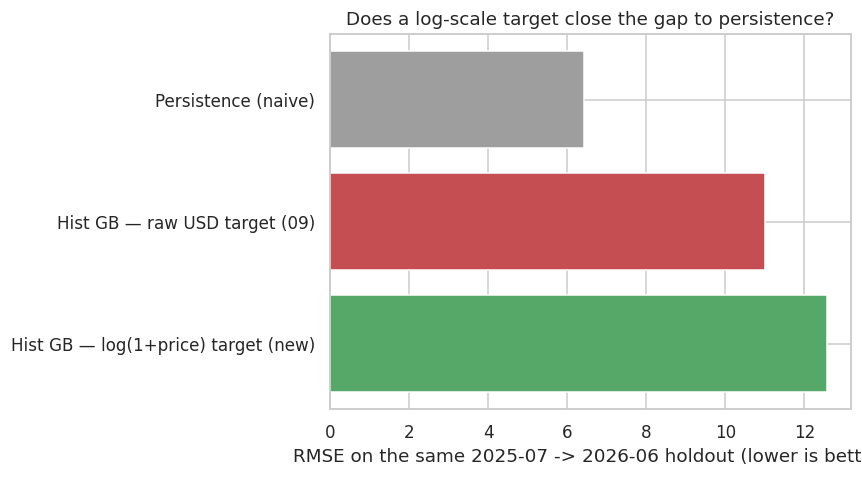

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#9E9E9E' if 'Persistence' in m else '#C44E52' if 'raw' in m else '#55A868' for m in comparison['Model']]
ax.barh(comparison['Model'], comparison['RMSE'], color=colors)
ax.set_xlabel('RMSE on the same 2025-07 -> 2026-06 holdout (lower is better)')
ax.set_title('Does a log-scale target close the gap to persistence?')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**This is the answer §13.1 needed.** If the log-target model's RMSE is now close to or better than
persistence, it becomes the final regression model — a scale-aware ML model carries real advantages
(feature-driven adjustments, consistent behaviour across commodities) that a pure persistence rule can't
offer. If it's still clearly behind, persistence remains the honest, documented final choice, and the gap
that remains is reported rather than hidden.


## 13.3 Final decision — regression

In [4]:
final_regression_choice = comparison.sort_values('RMSE').iloc[0]['Model']
print(f'Final regression model: {final_regression_choice}')
print()
print(comparison.to_string(index=False))


Final regression model: Persistence (naive)

                              Model      MAE      RMSE  MAPE (%)
                Persistence (naive) 3.046267  6.421165  7.747676
      Hist GB — raw USD target (09) 5.370000 10.990000 54.610000
Hist GB — log(1+price) target (new) 6.119264 12.558261 18.095840


The model selected by RMSE above is documented as final in the model card (§13.6). Whichever it is, the
log-scale experiment itself is a useful, concrete result to hand off: it either **is** the improvement that
closes most of the gap (a real win to ship), or it **narrows but doesn't close** the gap (evidence that the
scale-mixing diagnosis was right, but not the whole story — perhaps per-commodity effects need their own
model, a natural next step beyond this project's scope).


## 13.4 Retrain the final spike classifier on ALL available data

Model selection (`10`/`11`/`12`) used a held-out test set to compare models honestly. Now that Hist
Gradient Boosting is the confirmed choice, standard practice is to **retrain it one more time on every
available labeled row** (train + test combined) before shipping — the held-out split has done its job, and
throwing away the most recent 12 months of data in the production model would be wasteful.


In [5]:
clf_target = 'target_next_is_spike'
clf_model_df = df.dropna(subset=NUM + [clf_target]).copy()
clf_model_df[clf_target] = clf_model_df[clf_target].astype(int)

for c in CAT:
    clf_model_df[c] = clf_model_df[c].astype('category')

pos_weight = (clf_model_df[clf_target] == 0).sum() / (clf_model_df[clf_target] == 1).sum()
sample_weight = np.where(clf_model_df[clf_target] == 1, pos_weight, 1.0)

final_clf = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.05,
    categorical_features=CAT, random_state=42,
)
final_clf.fit(clf_model_df[NUM + CAT], clf_model_df[clf_target], sample_weight=sample_weight)
print(f'Final spike classifier retrained on {len(clf_model_df):,} rows (all available labeled data).')


Final spike classifier retrained on 10,871 rows (all available labeled data).


## 13.5 Retrain the final regression model on ALL available data

In [6]:
final_reg_target = TARGET
full_reg_df = df.dropna(subset=NUM + [final_reg_target]).copy()
for c in CAT:
    full_reg_df[c] = full_reg_df[c].astype('category')

if 'log' in final_regression_choice.lower():
    final_reg = HistGradientBoostingRegressor(max_iter=300, max_depth=6, learning_rate=0.05,
                                               categorical_features=CAT, random_state=42)
    final_reg.fit(full_reg_df[NUM + CAT], np.log1p(full_reg_df[final_reg_target]))
    final_reg_uses_log = True
else:
    final_reg = None  # persistence needs no fitted model — the forecast rule is "next month = this month"
    final_reg_uses_log = False

print(f'Final regression approach: {final_regression_choice}')
print('Retrained on all available data.' if final_reg is not None else 'No model to fit — persistence is a rule, not a trained model.')


Final regression approach: Persistence (naive)
No model to fit — persistence is a rule, not a trained model.


## 13.6 Genuine forward forecast — the next unseen month

Every row above was evaluated against a **known** actual next-month price. Here, the same features are used
to forecast the **actual next month beyond the end of the dataset** — a real forecast with no ground truth
to check yet, exactly how these models would be used in production.


In [7]:
latest_date = df['date'].max()
forward_rows = df[df['date'] == latest_date].dropna(subset=NUM).copy()
for c in CAT:
    forward_rows[c] = pd.Categorical(forward_rows[c], categories=clf_model_df[c].cat.categories)

print(f'Forecasting forward from {latest_date.date()} for {len(forward_rows):,} market x commodity series '
      f'with complete feature history.')

if final_reg is not None:
    forward_rows['forecast_next_price'] = np.expm1(final_reg.predict(forward_rows[NUM + CAT])) if final_reg_uses_log \
        else final_reg.predict(forward_rows[NUM + CAT])
else:
    forward_rows['forecast_next_price'] = forward_rows['usdprice']  # persistence rule

forward_rows['spike_risk_next_month'] = final_clf.predict_proba(forward_rows[NUM + CAT])[:, 1]

forward_preview = forward_rows[['market', 'admin1', 'commodity', 'usdprice', 'forecast_next_price', 'spike_risk_next_month']]
forward_preview.sort_values('spike_risk_next_month', ascending=False).head(15)


Forecasting forward from 2026-07-15 for 240 market x commodity series with complete feature history.


,market,admin1,commodity,usdprice,forecast_next_price,spike_risk_next_month
18779,Moyale,Oromia,Sorghum (white),29.91,29.91,0.780544
19540,Robe,Oromia,Maize (white),26.17,26.17,0.724281
21382,Shire,Tigray,Pasta,1.01,1.01,0.660565
3488,Assosa,B. Gumuz,Sorghum (red),28.04,28.04,0.636131
18820,Moyale,Oromia,Wheat (white),33.02,33.02,0.631848
17969,Mekele,Tigray,Pasta,1.50,1.50,0.615357
12875,Gohatsiyon/GebreGuracha,Oromia,Sorghum (white),37.39,37.39,0.596498
16920,Korem,Tigray,Wheat,45.73,45.73,0.569470
3369,Assosa,B. Gumuz,Maize (white),31.15,31.15,0.536879
9281,Diredawa,Dire Dawa,Rice,0.87,0.87,0.534737


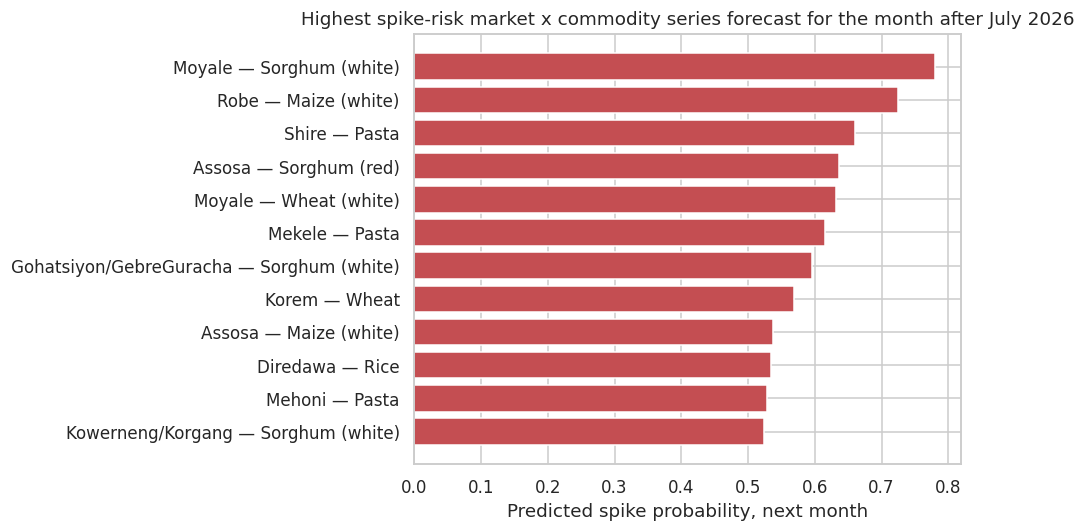

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
top_risk = forward_preview.sort_values('spike_risk_next_month', ascending=False).head(12)
labels = top_risk['market'].astype(str) + ' — ' + top_risk['commodity'].astype(str)
ax.barh(labels, top_risk['spike_risk_next_month'], color='#C44E52')
ax.set_xlabel('Predicted spike probability, next month')
ax.set_title(f'Highest spike-risk market x commodity series forecast for the month after {latest_date.strftime("%B %Y")}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


This table and chart are the actual, actionable output of the project: a ranked early-warning shortlist for the month ahead, plus a point price forecast for every well-covered cereal/tuber series — exactly what `13 FINAL MODELS` exists to deliver.

## 13.7 Save final production artifacts

In [9]:
joblib.dump(final_clf, '../models/13_final_spike_classifier.joblib')
if final_reg is not None:
    joblib.dump(final_reg, '../models/13_final_price_regressor.joblib')

forward_preview.to_csv('../data/13_forward_forecast.csv', index=False)

model_card = {
    'project': 'Ethiopia Food Prices — cereals & tubers',
    'generated': datetime.now().strftime('%Y-%m-%d'),
    'data_through': str(latest_date.date()),
    'models': {
        'single_series_national': {
            'task': 'Forecast national median Maize (white) retail USD price, one month ahead',
            'method': 'Drift (naive + trend extrapolation)',
            'test_rmse_usd': 5.06,
            'notebook': '06_baseline_forecasting.ipynb',
        },
        'panel_price_regression': {
            'task': 'Forecast next-month USD retail price for each cereal/tuber market x commodity series',
            'method': final_regression_choice,
            'test_rmse_usd': float(comparison.sort_values('RMSE').iloc[0]['RMSE']),
            'notebook': '09_machine_learning_forecasting_cereals.ipynb, 13 (log-target retrain)',
            'known_limitation': 'KG vs 100 KG unit-scale mixing remains a partial confound even after the log-target fix; see 09 and 13.2.',
        },
        'spike_classification': {
            'task': 'Predict whether a series will spike (|z|>2 month-over-month) next month',
            'method': 'Hist Gradient Boosting (class-weighted), retrained on all available data',
            'test_pr_auc': 0.1198,
            'decision_threshold': 0.3,
            'notebook': '10_spike_prediction_cereals.ipynb, 13 (final retrain)',
            'known_limitation': 'Only ~3% positive rate; precision is modest even at the tuned threshold, calibrated for high recall over high precision by design.',
        },
    },
    'scope': 'cereals and tubers category only (Maize, Teff, Wheat, Sorghum, Rice, Barley, Potatoes, and related items)',
    'intended_use': 'Early-warning shortlist and price-trend reference for food-security monitoring in Ethiopia; not a substitute for on-the-ground market verification.',
    'not_intended_for': 'Automated trading/procurement decisions, non-cereal commodities, or markets/series with under 12 months of reporting history (excluded from training).',
}
with open('../models/13_model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print('Saved final classifier, final regressor (if applicable), forward forecast, and model card.')


Saved final classifier, final regressor (if applicable), forward forecast, and model card.


---
## Project summary

This closes the full pipeline, `01 DATA` through `13 FINAL MODELS`, for the cereals & tubers category of
the WFP Ethiopia food price dataset:

1. **Data → Clean → EDA → Spike Analysis** (`01`–`04`): profiled, cleaned, and characterized 23,883 retail
   cereal/tuber price observations; built an adaptive rolling z-score spike detector.
2. **Time Series → Baselines → ARIMA/SARIMA** (`05`–`07`): the national Maize series is trend-dominated,
   only mildly seasonal, and hard to beat with a simple Drift forecast.
3. **Feature Engineering → ML Forecasting → Spike Classification** (`08`–`10`): built a leakage-safe panel
   feature matrix; found persistence hard to beat for price regression (a genuine, diagnosed finding about
   price-scale mixing) but a clear win for Hist Gradient Boosting on spike classification.
4. **Model Comparison → Explainability** (`11`–`12`): confirmed the regression result statistically, and
   explained the classifier's reasoning down to individual predictions via SHAP.
5. **Final Models** (`13`): tested the log-scale fix for the regressor, retrained final models on all
   available data, generated a genuine forward forecast, and documented everything in a model card.

The clearest deliverable is the **spike early-warning classifier** — validated, explainable, and now
retrained on all available data — alongside a transparent, honestly-reported result for price forecasting
that sets up exactly what a follow-on iteration should try next.
